# Cross-City Crash Hotspot Detection

**Status:** runs against the curated Parquet produced by the
`crash_pipeline` DAG. Run the DAG first, then run this notebook from
the `notebooks/` folder (Kernel → Restart & Run All).

**Scope:** one recent year per source, capped at `MAX_POINTS` points,
because density clustering on all 1.6M points does not fit in a
laptop's memory. The scope used is printed in every output.

**Interpretation cells** (marked *Finding*) are written from this
run's outputs. If the data or parameters change, re-run and update them.

## Purpose

Detect crash hotspots by clustering latitude/longitude pairs with a
density-based method (DBSCAN or HDBSCAN), and compare hotspot
characteristics across the three sources. The identical clustering
code runs on every city — the only thing that changes per source is
the input partition, not the algorithm or its parameters.

## Two rules for this notebook

**Rule 1 — only cluster rows with valid coordinates.** Filter on
`has_valid_coordinates = TRUE`, never on `latitude IS NOT NULL AND
longitude IS NOT NULL`. The latter passes the sentinel `(0,0)` rows,
which would put crashes in the Gulf of Guinea and produce a cluster
there. This is the exact failure mode documented in
`docs/data_dictionary.md`.

**Rule 2 — compare hotspot *patterns*, not crash *totals*.** Reporting
thresholds and coverage differ by city. Chicago counts crashes that
meet one reporting threshold; the UK, a national dataset with its own
police-force practices; NYC, its own standard. The pipeline exists to
compare the *shape* of patterns (where hotspots are, when they occur,
what severity mix they have), not raw counts. State this explicitly
in the writeup and in any chart caption that touches cross-city totals.

## Method choice: DBSCAN / HDBSCAN

Why density-based clustering rather than k-means:

- **No fixed k.** Crash hotspots are not evenly distributed; k-means
  forces every crash into one of k clusters, including isolated crashes
  that are not part of any hotspot. DBSCAN/HDBSCAN let isolated crashes
  be labelled as noise.
- **Non-spherical clusters.** Road networks produce elongated hotspots
  (along arterials). k-means assumes spherical clusters and would split
  those.
- **Density varies by city.** Chicago's urban core is denser than outer
  boroughs; HDBSCAN adapts to varying density, DBSCAN with a single
  `eps` does not. Start with HDBSCAN if available; fall back to DBSCAN
  with per-city `eps` tuning if HDBSCAN is not installed.

## Parameters

Clustering uses the **haversine** (great-circle) distance on
coordinates in radians, so DBSCAN's `eps` is set in **meters** and
converted to radians by dividing by the Earth's radius. A 150 m radius
therefore means 150 m in Chicago, NYC, and the UK alike, with no
per-latitude correction needed. HDBSCAN sidesteps
the `eps` question but still has `min_cluster_size` and `min_samples`,
which need to be chosen per city's density.

## 0. Setup

Imports, plotting, and a per-city loader that reads one partition of
curated Parquet.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

# hdbscan is optional; DBSCAN is the default and what the results below use.
try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

CURATED_ROOT = Path("../data/curated/fact_crash")
SOURCES = ["chicago_us", "nyc_us", "uk_stats19"]
EARTH_RADIUS_M = 6_371_000

# Scope and parameters, recorded here so every result can be reproduced.
YEAR = {"chicago_us": 2025, "nyc_us": None, "uk_stats19": 2024}  # None = all of NYC's window
MAX_POINTS = 50_000      # random sample cap per source (memory bound)
SEED = 42
EPS_METERS = 150         # neighborhood radius
MIN_SAMPLES = 10         # points within EPS_METERS needed to form a cluster core

print(f"HDBSCAN available: {HAS_HDBSCAN}")

HDBSCAN available: False


In [2]:
def load_spatial(source_id: str, year: int | None = None,
                 max_points: int | None = MAX_POINTS, seed: int = SEED) -> pd.DataFrame:
    """Load rows with valid coordinates for one source (optionally one year).

    Filters on has_valid_coordinates = TRUE (NOT on latitude IS NOT NULL),
    so the (0,0) sentinel rows are excluded. See notebook header, Rule 1.
    Reads through pyarrow.dataset with partition filters, so only the
    requested source/year partitions are scanned.
    """
    if not CURATED_ROOT.exists():
        raise FileNotFoundError(
            f"{CURATED_ROOT.resolve()} not found. Run the crash_pipeline DAG first, "
            f"and run this notebook from the notebooks/ folder."
        )
    dataset = ds.dataset(CURATED_ROOT, format="parquet", partitioning="hive")
    flt = (ds.field("source_id") == source_id) & (ds.field("has_valid_coordinates") == True)
    if year is not None:
        flt = flt & (ds.field("year") == year)
    df = dataset.to_table(
        filter=flt,
        columns=["crash_id", "source_id", "crash_timestamp_utc", "source_local_timezone",
                 "latitude", "longitude", "severity"],
    ).to_pandas()
    if max_points is not None and len(df) > max_points:
        df = df.sample(n=max_points, random_state=seed)
    return df.reset_index(drop=True)

## 1. Per-source coverage

How many coordinate-bearing crashes per source. A sanity check before
clustering — if a source has only a few hundred valid points, its
clustering result will not be meaningful and should be labelled as
such.

Expected order-of-magnitude from profiling: Chicago ~1.09M valid,
UK ~514K valid, NYC — fewer rows total but a similar proportion of
valid coordinates once the 2.3% sentinel share is excluded.

In [3]:
for s in SOURCES:
    df_s = load_spatial(s, YEAR[s], max_points=None)
    print(f"{s} (year={YEAR[s] or 'all'}): {len(df_s):,} coordinate-bearing crashes")

chicago_us (year=2025): 107,923 coordinate-bearing crashes
nyc_us (year=all): 19,911 coordinate-bearing crashes
uk_stats19 (year=2024): 100,916 coordinate-bearing crashes


## 2. The clustering function — one implementation, all cities

This is the load-bearing cell: a single function that runs on any
source's spatial partition. The point of the pipeline is that the
same clustering code works on every city, so this function must not
branch on `source_id`. Any per-city differences belong in the
parameters passed in, not in `if source_id == ...` inside the function.

Returns the input DataFrame plus a `cluster_id` column (`-1` for noise,
per DBSCAN/HDBSCAN convention).

In [4]:
def cluster_hotspots(
    df: pd.DataFrame,
    method: str = "dbscan",
    eps_meters: float = EPS_METERS,
    min_samples: int = MIN_SAMPLES,
    min_cluster_size: int = 30,
) -> pd.DataFrame:
    """Cluster crash coordinates into hotspots.

    Parameters
    ----------
    df : DataFrame with 'latitude' and 'longitude' columns (degrees).
    method : 'dbscan' (default) or 'hdbscan' (if installed).
    eps_meters : DBSCAN neighborhood radius in meters. Converted to
                 radians (eps_meters / Earth radius) because the haversine
                 metric works on radians.
    min_samples : DBSCAN / HDBSCAN neighborhood size.
    min_cluster_size : HDBSCAN only; minimum points to call a cluster.

    Returns
    -------
    Copy of df with an added 'cluster_id' column. -1 means noise.
    """
    coords = np.radians(df[["latitude", "longitude"]].to_numpy())

    if method == "hdbscan":
        if not HAS_HDBSCAN:
            raise ImportError("hdbscan is not installed; use method='dbscan'")
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                    min_samples=min_samples, metric="haversine")
    elif method == "dbscan":
        clusterer = DBSCAN(eps=eps_meters / EARTH_RADIUS_M, min_samples=min_samples,
                           metric="haversine", algorithm="ball_tree")
    else:
        raise ValueError(f"Unknown method: {method}")

    out = df.copy()
    out["cluster_id"] = clusterer.fit_predict(coords)
    return out

## 3. Cluster one source (example: Chicago)

Run the same function on one source end-to-end so the full pipeline
(load → cluster → summarize) is visible. Later sections loop over
all three sources.

Parameters (`EPS_METERS`, `MIN_SAMPLES`) are set once in the setup
cell and used for every city, so the results are comparable. Section 7
checks that they give stable results.

In [5]:
df_chi = cluster_hotspots(load_spatial("chicago_us", YEAR["chicago_us"]))
n_clusters = df_chi.loc[df_chi["cluster_id"] >= 0, "cluster_id"].nunique()
n_noise = (df_chi["cluster_id"] == -1).sum()
print(f"Chicago {YEAR['chicago_us']} ({len(df_chi):,} points, eps={EPS_METERS} m, "
      f"min_samples={MIN_SAMPLES}): {n_clusters} clusters, {n_noise:,} noise points "
      f"({n_noise/len(df_chi):.1%} of rows)")

Chicago 2025 (50,000 points, eps=150 m, min_samples=10): 607 clusters, 9,015 noise points (18.0% of rows)


## 4. Summarize a clustering result

For each cluster: size, centroid, severity mix, temporal profile.
This is the shape that goes into the writeup — a table of hotspots
with their characteristics, not just a scatter plot.

The same summarization runs on any source, so the outputs are directly
comparable in structure.

In [6]:
def summarize_clusters(df: pd.DataFrame) -> pd.DataFrame:
    """Per-cluster summary: size, centroid, severity mix, peak local hour.

    Excludes cluster_id == -1 (noise).
    """
    clustered = df[df["cluster_id"] >= 0]
    if clustered.empty:
        return pd.DataFrame(columns=["size", "centroid_lat", "centroid_lon",
                                     "pct_fatal", "pct_serious", "pct_minor", "peak_local_hour"])

    local_hour = pd.concat(
        g["crash_timestamp_utc"].dt.tz_convert(tz).dt.hour
        for tz, g in clustered.groupby("source_local_timezone")
    )
    sev = pd.crosstab(clustered["cluster_id"], clustered["severity"], normalize="index") * 100
    grouped = clustered.groupby("cluster_id")
    summary = pd.DataFrame({
        "size": grouped.size(),
        "centroid_lat": grouped["latitude"].mean().round(5),
        "centroid_lon": grouped["longitude"].mean().round(5),
        "pct_fatal": sev.get("fatal", 0.0),
        "pct_serious": sev.get("serious", 0.0),
        "pct_minor": sev.get("minor", 0.0),
        "peak_local_hour": local_hour.groupby(clustered["cluster_id"]).agg(lambda h: h.mode().iat[0]),
    })
    return summary.sort_values("size", ascending=False).round(2)

summarize_clusters(df_chi).head(10)

,size,centroid_lat,centroid_lon,pct_fatal,pct_serious,pct_minor,peak_local_hour
cluster_id,,,,,,,
15,6180,41.88,-87.63,0.02,1.07,12.77,17
70,1687,41.88,-87.74,0.06,2.25,20.15,15
17,1434,41.98,-87.66,0.00,1.39,12.27,16
34,1189,41.92,-87.75,0.17,1.51,14.47,16
32,883,41.94,-87.65,0.00,2.04,12.80,14
18,683,41.93,-87.70,0.15,1.02,13.18,15
8,645,41.95,-87.72,0.00,0.78,12.09,14
85,559,41.84,-87.71,0.00,0.72,14.13,14
33,544,41.79,-87.70,0.00,0.92,13.79,16


## 5. Run clustering across all three sources

The loop that produces the cross-city comparison. Same function, same
summarization, three inputs.

**Structural gap to annotate:** the `severity` mix within a cluster is
not comparable across all three sources. NYC cannot produce
`serious`, so its cluster summaries will show 0% serious by
construction, not by finding. When comparing severity mix across
cities, restrict to Chicago + UK, or collapse `serious` and `minor`
into a single `injury` bucket for the NYC-inclusive comparison. State
which choice was made in the writeup.

In [7]:
clustered_by_source, results = {}, {}
for s in SOURCES:
    df_s = cluster_hotspots(load_spatial(s, YEAR[s]))
    clustered_by_source[s] = df_s
    results[s] = summarize_clusters(df_s)
    noise = (df_s["cluster_id"] == -1).mean()
    print(f"{s} (year={YEAR[s] or 'all'}, {len(df_s):,} points): "
          f"{len(results[s])} clusters, noise {noise:.1%}")

chicago_us (year=2025, 50,000 points): 607 clusters, noise 18.0%
nyc_us (year=all, 19,911 points): 287 clusters, noise 73.2%
uk_stats19 (year=2024, 50,000 points): 50 clusters, noise 98.6%


## 6. Visualize hotspots — one city at a time

A scatter of crash points colored by cluster ID, per city, on its own
axes. Do **not** overlay all three cities on one map: they occupy
different geographies and different coordinate ranges, and overlaying
them makes each one's structure unreadable.

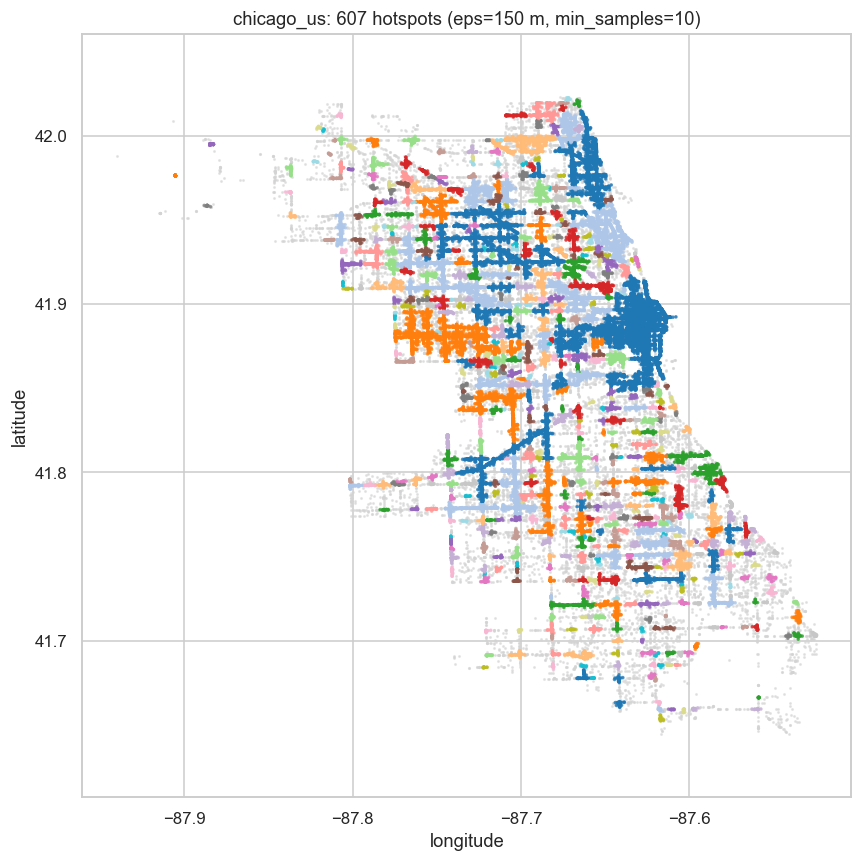

,size,centroid_lat,centroid_lon,pct_fatal,pct_serious,pct_minor,peak_local_hour
cluster_id,,,,,,,
15,6180,41.88,-87.63,0.02,1.07,12.77,17
70,1687,41.88,-87.74,0.06,2.25,20.15,15
17,1434,41.98,-87.66,0.00,1.39,12.27,16
34,1189,41.92,-87.75,0.17,1.51,14.47,16
32,883,41.94,-87.65,0.00,2.04,12.80,14
18,683,41.93,-87.70,0.15,1.02,13.18,15
8,645,41.95,-87.72,0.00,0.78,12.09,14
85,559,41.84,-87.71,0.00,0.72,14.13,14
33,544,41.79,-87.70,0.00,0.92,13.79,16


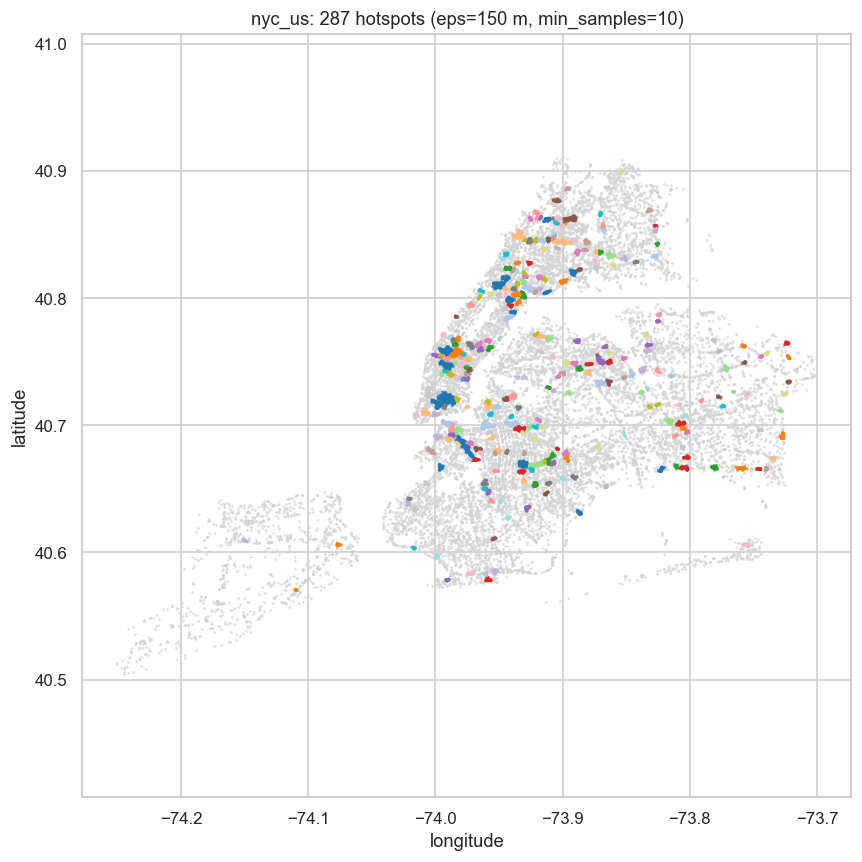

,size,centroid_lat,centroid_lon,pct_fatal,pct_serious,pct_minor,peak_local_hour
cluster_id,,,,,,,
7,179,40.72,-73.99,0.00,0.0,37.99,16
0,118,40.68,-73.98,0.00,0.0,36.44,15
31,83,40.76,-73.98,0.00,0.0,54.22,16
9,82,40.75,-73.99,0.00,0.0,39.02,13
15,74,40.70,-73.96,1.35,0.0,40.54,11
4,70,40.76,-73.99,0.00,0.0,28.57,22
56,65,40.85,-73.93,1.54,0.0,24.62,16
11,57,40.81,-73.95,1.75,0.0,40.35,16
85,57,40.70,-73.98,0.00,0.0,42.11,0


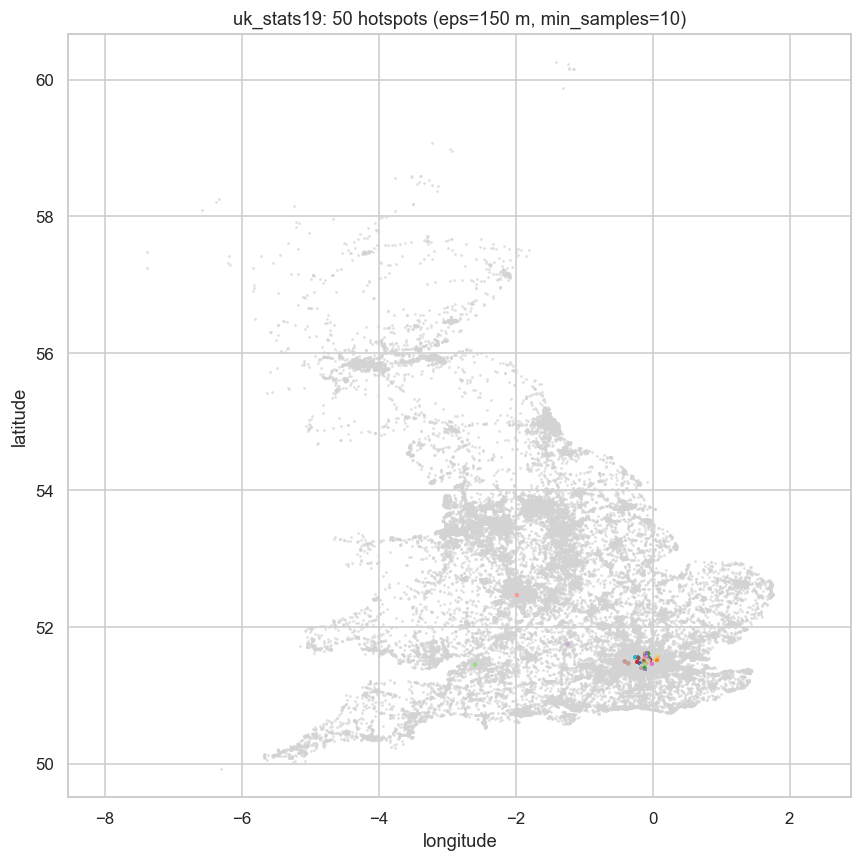

,size,centroid_lat,centroid_lon,pct_fatal,pct_serious,pct_minor,peak_local_hour
cluster_id,,,,,,,
10,29,51.52,-0.13,0.00,17.24,82.76,17
22,28,51.60,-0.11,3.57,14.29,82.14,19
7,28,51.49,-0.12,0.00,25.00,75.00,9
13,25,51.46,-0.12,0.00,4.00,96.00,21
6,19,51.55,-0.08,0.00,15.79,84.21,17
21,18,51.62,-0.09,0.00,11.11,88.89,22
3,18,51.53,-0.09,0.00,16.67,83.33,19
5,17,51.52,0.06,0.00,17.65,82.35,8
20,17,51.39,-0.11,0.00,11.76,88.24,17


In [8]:
def plot_hotspots(df: pd.DataFrame, title: str):
    """Scatter crashes colored by cluster_id. Noise (-1) is grey."""
    fig, ax = plt.subplots(figsize=(8, 8))
    clustered = df[df["cluster_id"] >= 0]
    noise = df[df["cluster_id"] == -1]
    ax.scatter(noise["longitude"], noise["latitude"],
               s=1, c="lightgrey", label="noise", alpha=0.5)
    ax.scatter(clustered["longitude"], clustered["latitude"],
               s=2, c=clustered["cluster_id"], cmap="tab20", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()


for s in SOURCES:
    plot_hotspots(clustered_by_source[s],
                  f"{s}: {len(results[s])} hotspots (eps={EPS_METERS} m, min_samples={MIN_SAMPLES})")
    display(results[s].head(10))


## 7. Cluster stability

Cross-city comparison is only meaningful if the clusters are stable —
re-running with slightly different parameters should produce roughly
the same hotspot geography, not a completely different one.

A simple check: re-run clustering on a random 80% subsample of each
city's points and compare the resulting cluster count and mean cluster
size. Large swings indicate the parameters are too sensitive for the
result to be interpreted.

In [9]:
for s in SOURCES:
    df_s = load_spatial(s, YEAR[s])
    for seed in [0, 1, 2]:
        sample = df_s.sample(frac=0.8, random_state=seed)
        clustered = cluster_hotspots(sample)
        n_clusters = clustered.loc[clustered["cluster_id"] >= 0, "cluster_id"].nunique()
        mean_size = clustered.loc[clustered["cluster_id"] >= 0].groupby("cluster_id").size().mean()
        print(f"{s} seed={seed}: {n_clusters} clusters, mean size {mean_size:.0f}")

chicago_us seed=0: 661 clusters, mean size 46
chicago_us seed=1: 663 clusters, mean size 45
chicago_us seed=2: 657 clusters, mean size 46
nyc_us seed=0: 180 clusters, mean size 16
nyc_us seed=1: 174 clusters, mean size 16
nyc_us seed=2: 166 clusters, mean size 16
uk_stats19 seed=0: 25 clusters, mean size 12
uk_stats19 seed=1: 24 clusters, mean size 12
uk_stats19 seed=2: 19 clusters, mean size 13


**Finding.**

*Chicago gives a usable hotspot map.* On a 50,000-point sample of 2025
crashes, DBSCAN (150 m, 10 points) found 607 hotspots with 18.0% noise,
well inside the 30% guideline in the notes below. The map shows that
Chicago's hotspots are **corridors, not points**: clusters run along
arterial roads, which is the elongated shape that motivated density-based
clustering over k-means. The largest cluster (6,180 points, centred near
41.88°N, 87.63°W) is downtown around the Loop; DBSCAN chains its dense,
adjacent blocks into one region, so it represents downtown as a whole
rather than a single intersection. The largest hotspots peak between
14:00 and 17:00, matching the citywide afternoon peak, and their severity
mix (0–0.17% fatal, about 1–2% serious) is close to the citywide rates,
so in Chicago the hotspots concentrate crash *volume* rather than
unusually severe crashes.

*The results are stable where the data is dense.* Re-clustering 80%
subsamples gave 657–663 clusters for Chicago and 166–180 for NYC across
three seeds, but only 19–25 for the UK.

*NYC is indicative only.* Its 19,911 points (one 90-day window) gave 287
clusters but 73.2% noise, far above the 30% guideline: three months of
data is too sparse for these parameters. The largest clusters are in
Lower and Midtown Manhattan (around 40.72–40.76°N, 73.98–73.99°W) and in
Brooklyn near 40.68°N, 73.98°W, but this is not a complete hotspot map.

*The UK result is not meaningful at these parameters.* With 98.6% noise,
only 50 clusters formed, almost all in Greater London, with a handful
near Birmingham and Bristol. A 150 m / 10-point rule suits one city's
density, not a national dataset spread across Great Britain. The high
serious share inside the London clusters (4–25%) again reflects that
STATS19 records only injury collisions.

*For the project problem:* the same clustering code ran unchanged on all
three sources, as the pipeline intends, but one parameter set does not
transfer across sources with very different densities. Chicago supports a
defensible hotspot analysis now. NYC needs a longer window, and the UK
needs per-city clustering (for example by local authority) or HDBSCAN,
which adapts to varying density.

## 8. Notes for anyone extending this notebook

1. **Filter on `has_valid_coordinates`, not on coordinate non-nullness.**
   The sentinel `(0,0)` rows will pass a null check and place crashes
   in the Gulf of Guinea. This is the exact failure mode the pipeline's
   `has_valid_coordinates` column exists to prevent.

2. **Do not branch on `source_id` inside the clustering function.**
   The whole point of the pipeline is that the same algorithm applies
   to every city. Per-city differences belong in parameters
   (`min_cluster_size`, `eps`), passed in by the caller.

3. **Keep `eps` in meters.** The haversine metric works in radians,
   so `cluster_hotspots` converts `eps_meters` to radians by dividing
   by the Earth's radius. Passing a value in degrees would silently use
   a radius about 64 times larger than intended.

4. **Report the noise fraction.** DBSCAN/HDBSCAN leave some points
   unclustered. A noise fraction above ~30% is a signal that the
   parameters are wrong for the data's density, not that the data has
   no hotspots.

5. **State the cross-city caveat in the writeup.** Crash counts depend
   on each city's reporting thresholds and practices. The notebook's
   contribution is that hotspot *patterns* are comparable — where
   clusters are, what their severity mix looks like, when their
   crashes occur — not that crash *totals* are comparable across
   cities. Do not present a cross-city bar chart of raw crash counts
   as a finding.

6. **Document the parameters used, in the notebook, for each run.**
   `min_cluster_size`, `min_samples`, `eps`, and the method chosen.
   HDBSCAN's defaults are not always right; DBSCAN's `eps` is
   almost never right without tuning. Whoever reads the results
   needs to know what produced them.